# 🧪 Laboratorio Interactivo: Agente Emma (OfficeFlow Supply Co.)

¡Bienvenido a este cuaderno de experimentación interactiva! Este notebook complementa el curso **Building Reliable Agents** de LangChain Academy.

Aquí podrás:
1. **Ver el grafo de arquitectura** y entender el flujo de decisión del agente.
2. **Inspeccionar la base de datos real SQLite** (`inventory.db`) con `pandas`.
3. **Probar a Emma celda por celda** utilizando tu servidor local de **Ollama** (`qwen2.5:7b` + `nomic-embed-text`) en tu GPU **NVIDIA RTX 3060** a coste $0.
4. **Analizar las llamadas a herramientas y trazas** registradas en tu proyecto de **LangSmith**.

## 1. 🗺️ Visualización del Grafo de Arquitectura

Emma opera mediante un **patrón de bucle de herramientas (Tool-Calling Loop)**:

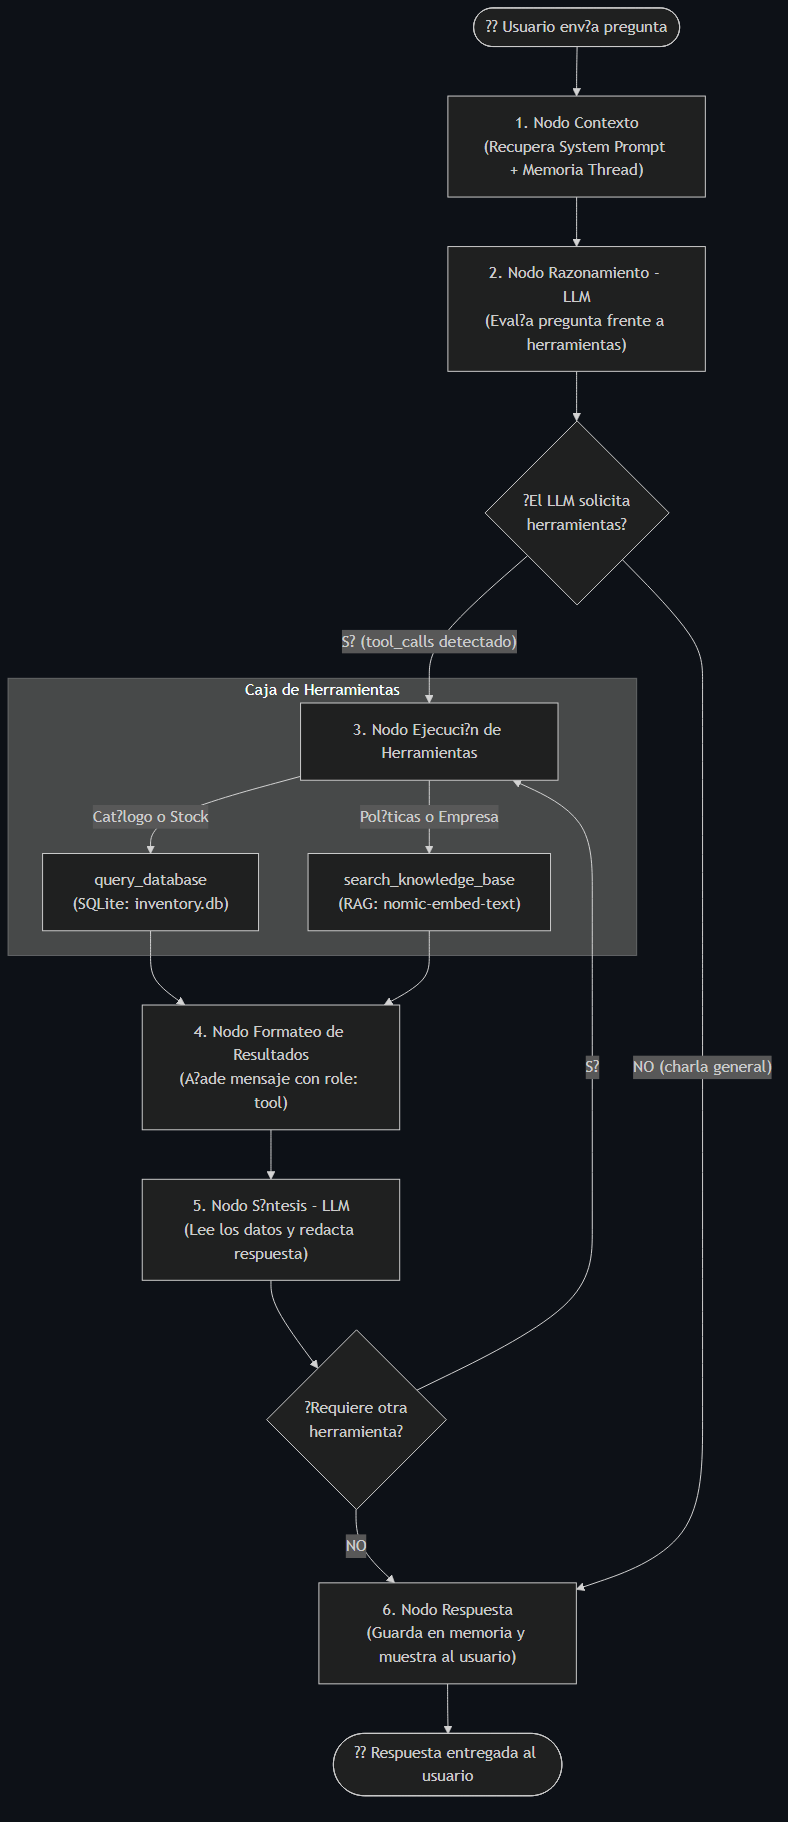

In [1]:
import os
from IPython.display import Image, display

# Cargamos el diagrama compilado con Mermaid
graph_path = os.path.abspath(os.path.join("..", "architecture_graph.png"))
if os.path.exists(graph_path):
    display(Image(filename=graph_path, width=800))
else:
    print("El archivo de arquitectura no se encontró en la ruta esperada.")

## 2. ⚙️ Configuración del Entorno y Verificación de Modelos

Cargamos las variables de entorno desde el archivo `.env`.

In [ ]:
from dotenv import load_dotenv

# Cargamos el archivo .env de la raíz del curso
load_dotenv(os.path.abspath(os.path.join("..", ".env")))

base_url = os.getenv("OPENAI_BASE_URL", "http://localhost:11434/v1")
chat_model = os.getenv("CHAT_MODEL", "qwen2.5:7b")
embed_model = os.getenv("EMBEDDING_MODEL", "nomic-embed-text")
langsmith_project = os.getenv("LANGSMITH_PROJECT", "lca-reliable-agents")
langsmith_tracing = os.getenv("LANGSMITH_TRACING", "false")

print("=== ESTADO DEL ENTORNO ===")
print(f"📡 Endpoint API:         {base_url}")
print(f"🧠 Modelo de Chat:        {chat_model}")
print(f"📐 Modelo de Embeddings:  {embed_model}")
print(f"📊 Proyecto LangSmith:    {langsmith_project}")
print(f"🔍 Trazabilidad Activa:   {langsmith_tracing}")

## 3. 🗄️ Inspección Visual de la Base de Datos (`inventory.db`)

Veamos con qué datos reales cuenta Emma en el almacén de OfficeFlow.

In [ ]:
import sqlite3
import pandas as pd

db_path = os.path.abspath(os.path.join("inventory", "inventory.db"))
conn = sqlite3.connect(db_path)

# Consultamos los productos y sus existencias combinando ambas tablas
query = """
SELECT 
    i.item_id AS 'ID',
    i.sku_label AS 'Descripción del Producto',
    s.available_units AS 'Unidades Disponibles'
FROM items i
LEFT JOIN stock_levels s ON i.item_id = s.item_id
ORDER BY s.available_units DESC;
"""

df_inventario = pd.read_sql_query(query, conn)
conn.close()

print(f"Total de artículos registrados en inventario: {len(df_inventario)}\n")
df_inventario.head(10)

## 4. 🚀 Inicializar el Agente y Cargar la Base de Conocimiento

Cargamos los documentos de políticas corporativas en memoria.

In [ ]:
import agent_v1
from agent_v1 import chat, load_knowledge_base

# Cargamos la base de conocimiento (usa la caché local embeddings_nomic...json)
await load_knowledge_base()
print("\n✅ Agente Emma listo para interactuar con soporte de LangSmith Tracing.")

## 5. 💬 Prueba 1: Consulta de Productos y Base de Datos SQL

Le preguntaremos a Emma sobre artículos en stock. Observaremos si decide usar `query_database`.

In [ ]:
from IPython.display import Markdown

pregunta_1 = "Hola Emma, ¿qué tipos de bolígrafos tienen y qué disponibilidad tienen en almacén?"
print(f"Tú: {pregunta_1}\n")

# Invocamos al agente
resultado_1 = await chat(pregunta_1)

# Mostramos la respuesta final generada
display(Markdown(f"**Emma:** {resultado_1['output']}"))

### 🔍 Inspección Anatómica de la Respuesta
Veamos los mensajes internos que ocurrieron entre bambalinas (llamadas a herramientas y respuestas):

In [ ]:
print(f"Thread ID de la conversación: {agent_v1.thread_id}\n")

for i, msg in enumerate(resultado_1["messages"]):
    rol = msg.get("role", "")
    if rol == "system":
        continue  # Omitimos el system prompt largo por legibilidad
    print(f"--- [Paso {i}] Rol: {rol.upper()} ---")
    if "tool_calls" in msg and msg["tool_calls"]:
        for tc in msg["tool_calls"]:
            print(f"  🛠️ Invocó Tool: {tc['function']['name']}")
            print(f"  📥 Argumentos: {tc['function']['arguments']}")
    elif rol == "tool":
        print(f"  📤 Salida de Tool: {msg.get('content')}")
    else:
        contenido = msg.get("content", "")
        print(f"  💬 Texto: {contenido[:150]}..." if len(contenido) > 150 else f"  💬 Texto: {contenido}")
    print()

## 6. 📚 Prueba 2: Consulta de Políticas Corporativas (RAG)

Ahora haremos una pregunta sobre devoluciones para forzar el uso de `search_knowledge_base`.

In [ ]:
pregunta_2 = "¿Cuál es la política de devoluciones de la empresa y cuántos días tengo para devolver un producto?"
print(f"Tú: {pregunta_2}\n")

resultado_2 = await chat(pregunta_2)
display(Markdown(f"**Emma:** {resultado_2['output']}"))

## 7. 🧪 Laboratorio Libre: Haz tu propia pregunta a Emma

Modifica la variable `mi_pregunta` y corre la celda:

In [ ]:
# Escribe aquí lo que quieras probar:
mi_pregunta = "¿Tienen papel de copia para entrega inmediata?"

mi_resultado = await chat(mi_pregunta)
display(Markdown(f"**Emma:** {mi_resultado['output']}"))

## 8. 📊 Visualización en LangSmith Tracing

Todas las consultas que acabas de ejecutar en este notebook se registraron en tu panel de LangSmith con el identificador de sesión activo:

1. Ingresa a [https://smith.langchain.com/](https://smith.langchain.com/).
2. Selecciona el proyecto: **`lca-reliable-agents`**.
3. En la barra de filtros, busca:
   `metadata.thread_id == "..."` (el ID impreso arriba).
4. Observa el árbol de ejecución jerárquico (*Run Tree*), los tokens consumidos y las latencias de cada llamada a herramientas.

---